In [104]:
import sys
import os
import pandas as pd
import numpy as np
import scipy.stats as st
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

source_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(source_path)
title_size=25
label_size=20
legend_size=14
tick_size=20

# initialization

In [93]:
output_dir_preprocessed = source_path + "\\outputs\\preprocessed_data\\"
LOG_FILE_preprocessed = output_dir_preprocessed+"file_metadata_log.json"
df_pre = file_IO.assemble_csv_from_log(LOG_FILE_preprocessed)
df_pre['created'] = pd.to_datetime(df_pre['created'])
df_pre['experiment'] = df_pre['experiment'].apply(lambda x: os.path.basename(str(x)))

#I divide the table into: patch datasets used for training, files with the extracted representations, contrastive learning datasets
# Assign dataset type based on conditions
df_pre.loc[
    ~df_pre['experiment'].str.contains('EXTRACTED', case=False) &
    ~df_pre['experiment'].str.contains('iam', case=False) &
    ~df_pre['experiment'].str.contains('KAGGLE', case=False),
    'type of dataset'
] = 'patch datasets used for training'

df_pre.loc[
    df_pre['experiment'].str.contains('KAGGLE', case=False),
    'type of dataset'
] = 'handcrafted features'

df_pre.loc[
    df_pre['experiment'].str.contains('EXTRACTED', case=False),
    'type of dataset'
] = 'extracted representations'

df_pre.loc[
    df_pre['experiment'].str.contains('iam', case=False),
    'type of dataset'
] = 'contrastive learning datasets'
df_pre['type of dataset'] = df_pre['type of dataset'].fillna('none')
df_pre_extracted = df_pre[df_pre['type of dataset'] == 'extracted representations']
df_pre_contrastive = df_pre[df_pre['type of dataset'] == 'contrastive learning datasets']
df_pre_handcrafted = df_pre[df_pre['type of dataset'] == 'handcrafted features']
df_pre_patch = df_pre[df_pre['type of dataset'] == 'patch datasets used for training']

experiments_to_remove = [
    'icdar_EXTRACTED_train_df_resnet50_20250516_163737.csv',
    'icdar_EXTRACTED_train_df_crnn_vgg16_bn_20250520_161925.csv',
    'icdar_EXTRACTED_train_df_crnn_vgg16_bn_20250520_165111.csv'
]
df_pre_extracted = df_pre_extracted[~df_pre_extracted['experiment'].isin(experiments_to_remove)]
print(len(df_pre_extracted))

import numpy as np
df_pre_patch['type'] = np.nan
mask = ((df_pre_patch['prop'].isna()) | (df_pre_patch['prop'] == 1)) & (df_pre_patch['gw'].notna())
df_pre_patch.loc[mask, 'type'] = 'squares'
mask = df_pre_patch['prop']<1
df_pre_patch.loc[mask, 'type'] = 'rectangles'
mask = ~df_pre_patch['n_slices'].isna()
df_pre_patch.loc[mask, 'type'] = 'sentences'
mask = ~df_pre_patch['fraction of the max used to identify boundaries'].isna()
df_pre_patch.loc[mask, 'type'] = 'body'
mask = df_pre_patch['type'].isna()
df_pre_patch.loc[mask, 'type'] = 'full images'

df_pre_patch['type_index'] = df_pre_patch.groupby(['type','gw','m patches'], dropna=False).cumcount() + 1
df_pre_patch['unique name'] = df_pre_patch.apply(
    lambda row: f"{row['type']}_gw{row['gw']}_m{row['m patches']}_idx{row['type_index']}", axis=1
)

unique_models = df_pre_extracted['model'].unique()
unique_names = df_pre_patch['unique name'].unique()
unique_names = sorted(unique_names)
df_visualization = pd.DataFrame(columns=['model'] + list(unique_names))

df_visualization['model'] = unique_models
for model in unique_models:
    for unique_name in unique_names:
        # Find the experiment corresponding to this unique_name in df_pre_patch
        exp_row = df_pre_patch[df_pre_patch['unique name'] == unique_name]
        if not exp_row.empty:
            experiment_value = exp_row.iloc[0]['experiment']
            # Check if there is a row in df_pre_extracted with this model and source file
            match = df_pre_extracted[
                (df_pre_extracted['model'] == model) &
                (df_pre_extracted['source_file'] == experiment_value)
            ]
            if not match.empty:
                df_visualization.loc[df_visualization['model'] == model, unique_name] = 1

191


C:\Users\andre\AppData\Local\Temp\ipykernel_16188\2153398704.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pre_patch['type'] = np.nan
C:\Users\andre\AppData\Local\Temp\ipykernel_16188\2153398704.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'squares' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_pre_patch.loc[mask, 'type'] = 'squares'
C:\Users\andre\AppData\Local\Temp\ipykernel_16188\2153398704.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.py

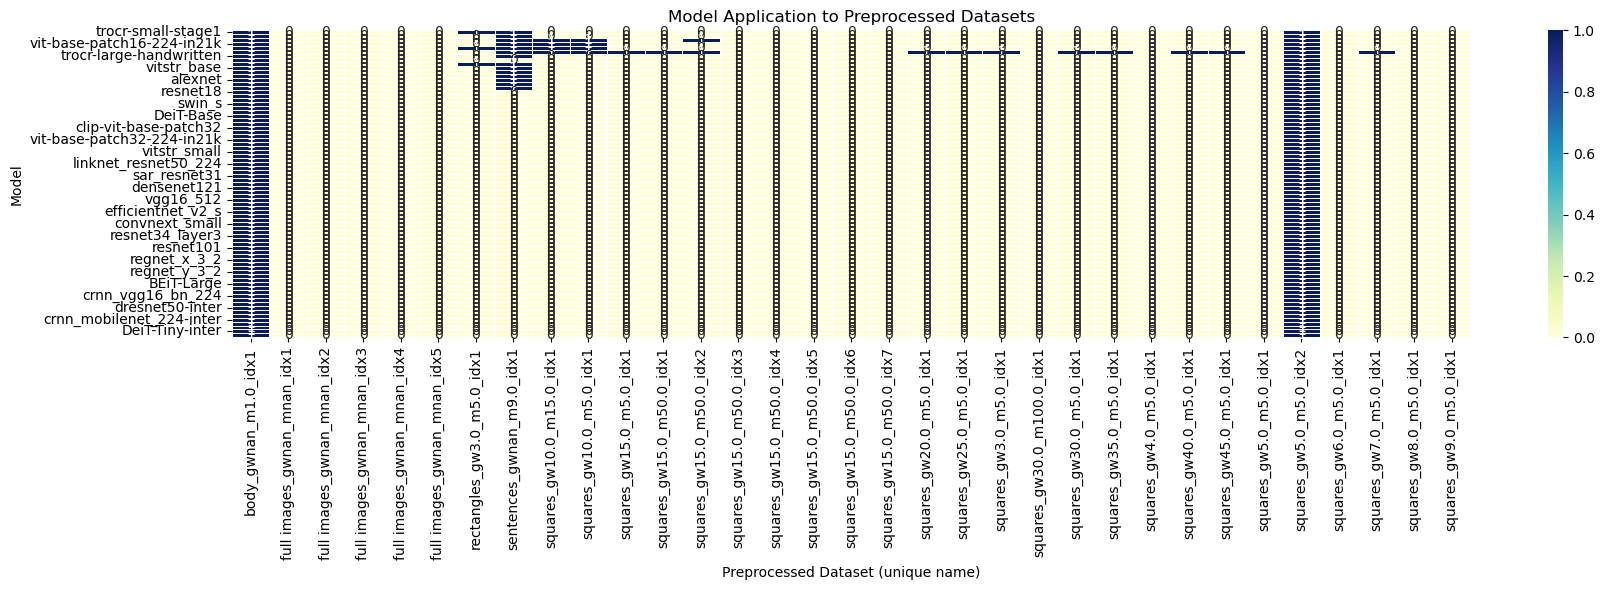

In [94]:
import seaborn as sns

import matplotlib.pyplot as plt

# Convert the DataFrame to numeric (1 for applied, 0 or NaN for not applied)
viz_numeric = df_visualization.copy()
viz_numeric = viz_numeric.set_index('model')
viz_numeric = viz_numeric.apply(pd.to_numeric, errors='coerce').fillna(0)

plt.figure(figsize=(18, 6))
sns.heatmap(viz_numeric, annot=True, cmap='YlGnBu', cbar=True, linewidths=0.5)
plt.title('Model Application to Preprocessed Datasets')
plt.xlabel('Preprocessed Dataset (unique name)')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

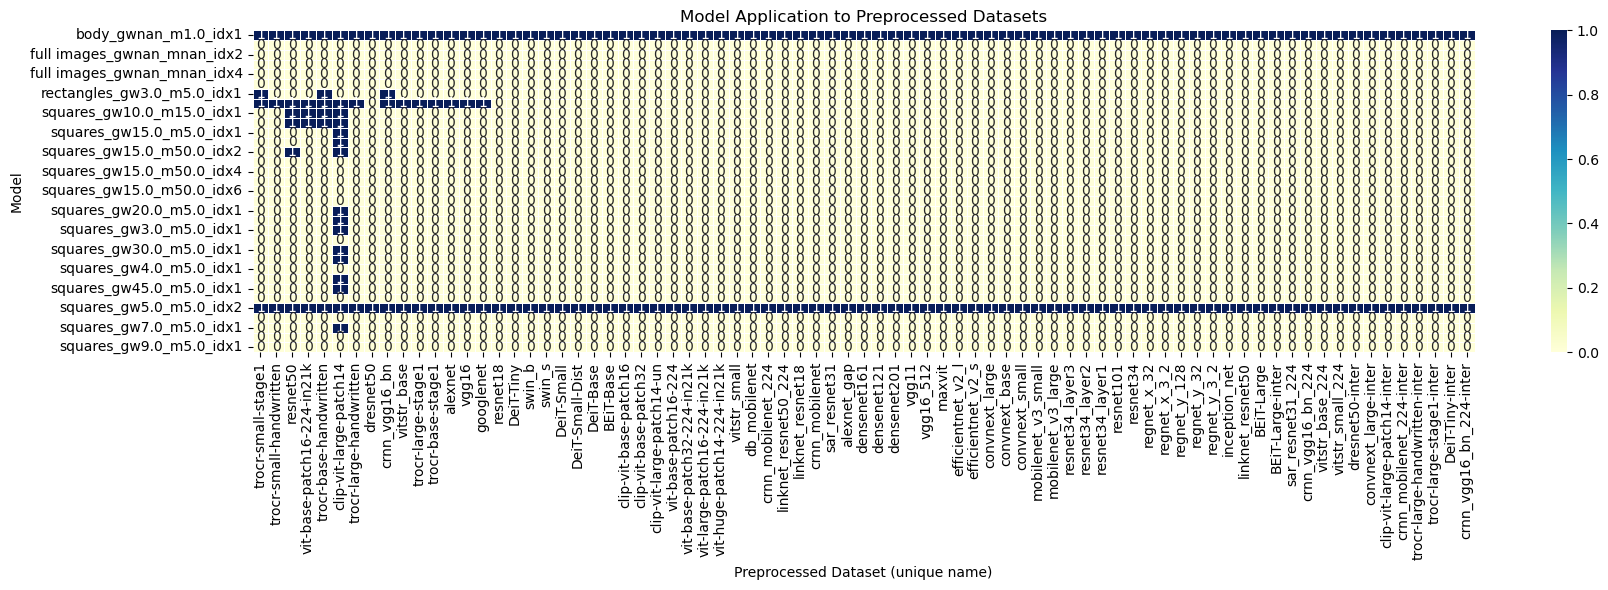

In [95]:
viz_numeric_T = viz_numeric.transpose()
plt.figure(figsize=(18, 6))
sns.heatmap(viz_numeric_T, annot=True, cmap='YlGnBu', cbar=True, linewidths=0.5)
plt.title('Model Application to Preprocessed Datasets')
plt.xlabel('Preprocessed Dataset (unique name)')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

# loading data

In [96]:
output_dir = os.path.join(source_path, "outputs", "preprocessed_data")
#experiment_csv = os.path.join(output_dir, "experiment_table.csv")
#experiment_csv = os.path.join(output_dir, "experiment_table_20250702_193304.pkl")
#experiment_csv = os.path.join(output_dir, "experiment_table_20250711_154537.pkl")
experiment_csv = os.path.join(output_dir, "experiment_table_20250830_183443.pkl")
df_experiments = pd.read_pickle(experiment_csv)  # Use read_csv if the file is in CSV format

In [97]:
import glob
import re
folder=source_path+'\\outputs\\logs\\feature_extraction'
print(folder)
feature_files = glob.glob(os.path.join(folder, "*.json"))
print(len(feature_files))
def extract_number_from_filename(filepath):
    # Extract the base name
    base = os.path.basename(filepath)
    # Find the last underscore followed by digits before the extension
    match = re.search(r'_(\d+)\.json$', base)
    if match:
        return int(match.group(1))
    else:
        return -1  # or some default if no match

# Sort the files by the extracted number
feature_files = sorted(feature_files, key=extract_number_from_filename)
print([os.path.basename(f) for f in feature_files])

all_ensembling_approaches = ['individual','ensembled','ensembled_weighted','ensembled_most_probable','ensembled_writers']
best_metric='ensembled_weighted'
all_groups=['english,different',
 'english,same',
 'arabic,different',
 'arabic,same',
 'english,all',
 'arabic,all',
 'all,different',
 'all,same']
IF_OOF = ['IF','OOF']
all_metrics = ['Mean','Min','Max','Variance','Median','Confidence Interval','Generalization Gap']

c:\Users\andre\VsCode\PD related projects\gender_detection\outputs\logs\feature_extraction
14
['results_experiment_1.json', 'results_experiment_2.json', 'results_experiment_3.json', 'results_experiment_4.json', 'results_experiment_5.json', 'results_experiment_6.json', 'results_experiment_7.json', 'results_experiment_8.json', 'results_experiment_9.json', 'results_experiment_10.json', 'results_experiment_11.json', 'results_experiment_12.json', 'results_experiment_13.json', 'results_experiment_14.json']


# vs size of patches

In [105]:
experiment=feature_files[2]
df = file_IO.assemble_csv_from_log(experiment)
df=extends_with_info_from_source(df,df_pre_patch,columns=['unique name', 'type','gw'])
features_of_interest = ['FE model','classifier model','with PCA','unique name','type','gw']
df = df[features_of_interest+['cross_val_accuracies','cross_val_subgroup_accuracies']]
df_exp=expand_accuracies(df, all_ensembling_approaches,all_groups)
df_exp.columns
selected_accuracies = select_accuracies(all_ensembling_approaches, ['OOF','IF'], ['Mean','Generalization Gap'], ['all,all'])
print(selected_accuracies)
#ensembling_types=['ensembled'],IF_OOF=['OOF'],metrics=['Mean'],groups=['all,all','english,all']
df=df_exp[features_of_interest+selected_accuracies]

df[features_of_interest+['ensembled_weighted_OOF_accuracy_Mean']]
df = df[df['unique name'] != 'squares_gw15.0_m50.0_idx1']

['individual_OOF_accuracy_Mean', 'individual_Generalization Gap', 'individual_IF_accuracy_Mean', 'ensembled_OOF_accuracy_Mean', 'ensembled_Generalization Gap', 'ensembled_IF_accuracy_Mean', 'ensembled_weighted_OOF_accuracy_Mean', 'ensembled_weighted_Generalization Gap', 'ensembled_weighted_IF_accuracy_Mean', 'ensembled_most_probable_OOF_accuracy_Mean', 'ensembled_most_probable_Generalization Gap', 'ensembled_most_probable_IF_accuracy_Mean', 'ensembled_writers_OOF_accuracy_Mean', 'ensembled_writers_Generalization Gap', 'ensembled_writers_IF_accuracy_Mean']


In [106]:
x= df['gw']
y1 = df['ensembled_weighted_OOF_accuracy_Mean']
y2 = df['individual_OOF_accuracy_Mean']
#y3 = df['ensembled_weighted_IF_accuracy_Mean']
#y4 = df['individual_IF_accuracy_Mean']
# Sort by x to connect each point to the next closest on x axis
sorted_idx = np.argsort(x)
x_sorted = x.iloc[sorted_idx].values
y1_sorted = y1.iloc[sorted_idx].values
y2_sorted = y2.iloc[sorted_idx].values
#y3_sorted = y3.iloc[sorted_idx].values
#y4_sorted = y4.iloc[sorted_idx].values

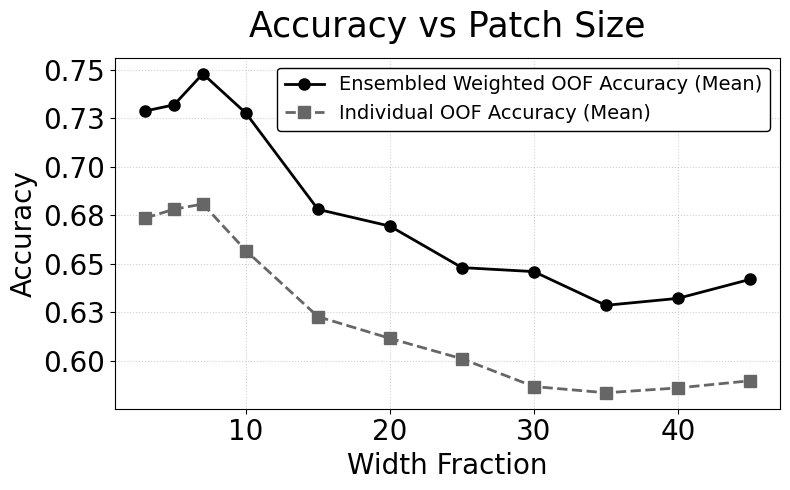

In [107]:
plt.figure(figsize=(8, 5))

# Line 1: Solid black with circles
plt.plot(x_sorted, y1_sorted, 
         color='0.0',           # Pure black
         linestyle='-',         # Continuous line
         marker='o',            # Circle marker
         markersize=8,          # Increased for visibility
         linewidth=2.0,         # Slightly thicker for print
         label='Ensembled Weighted OOF Accuracy (Mean)')

# Line 2: Dashed dark gray with squares
plt.plot(x_sorted, y2_sorted, 
         color='0.4',           # Dark gray
         linestyle='--',        # Dashed line
         marker='s',            # Square marker
         markersize=8,          # Increased for visibility
         linewidth=2.0,         # Slightly thicker for print
         label='Individual OOF Accuracy (Mean)')

# --- Enhanced Styling for Springer LNCS ---

# 1. Y-Axis: 2 significant digits
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

# 2. Font Sizes: Large and clear
plt.xlabel('Width Fraction', fontsize=label_size)#, fontweight='bold')
plt.ylabel('Accuracy', fontsize=label_size)#, fontweight='bold')
plt.xticks(fontsize=tick_size)
plt.yticks(fontsize=tick_size)

# 3. Legend: Bigger and positioned in the "empty" space
# 'loc' can be 'lower right', 'upper left', etc. 'best' finds the emptiest spot.
plt.legend(fontsize=legend_size, 
           loc='best',  frameon=True, framealpha=1.0, edgecolor='black')
# 4. Final Polish
plt.grid(True, linestyle=':', alpha=0.6)
plt.title('Accuracy vs Patch Size', fontsize=title_size, pad=15)
plt.tight_layout()

# Save with tight bounding box to prevent margin issues in LaTeX
plt.savefig('performance_with_gw.pdf', bbox_inches='tight')

# vs number of patches

In [108]:
experiment=feature_files[3]
df = file_IO.assemble_csv_from_log(experiment)
for i in range(len(df)):
    print(f"Row {i}: {df['experiment'].iloc[i]}")
df=extends_with_info_from_source(df,df_pre_patch,columns=['unique name', 'type','gw'])
features_of_interest = ['FE model','classifier model','with PCA','unique name','type','n_sub_patches']
print(list(df))

Row 0: 1_20250714_211003
Row 1: 2_20250714_211017
Row 2: 3_20250714_211032
Row 3: 4_20250714_211050
Row 4: 5_20250714_211111
Row 5: 6_20250714_211134
Row 6: 7_20250714_211158
Row 7: 8_20250714_211225
Row 8: 9_20250714_211254
Row 9: 10_20250714_211324
Row 10: 11_20250714_211356
Row 11: 12_20250714_211431
Row 12: 13_20250714_211507
Row 13: 14_20250714_211546
Row 14: 15_20250714_211627
Row 15: 16_20250714_211636
Row 16: 17_20250714_211646
Row 17: 18_20250714_211656
Row 18: 19_20250714_211707
Row 19: 20_20250714_211718
Row 20: 21_20250714_211731
Row 21: 22_20250714_211744
Row 22: 23_20250714_211758
Row 23: 24_20250714_211814
Row 24: 25_20250714_211830
Row 25: 26_20250714_211847
Row 26: 27_20250714_211905
Row 27: 28_20250714_211924
Row 28: 29_20250714_211944
Row 29: 30_20250714_212004
Row 30: 31_20250714_212017
Row 31: 32_20250714_212030
Row 32: 33_20250714_212045
Row 33: 34_20250714_212059
Row 34: 35_20250714_212115
Row 35: 36_20250714_212131
Row 36: 37_20250714_212148
Row 37: 38_20250714_

In [109]:
df = df[features_of_interest+['cross_val_accuracies','cross_val_subgroup_accuracies']]
df_exp=expand_accuracies(df, all_ensembling_approaches,all_groups)
df_exp.columns
selected_accuracies = select_accuracies(all_ensembling_approaches, ['OOF','IF'], ['Mean','Generalization Gap'], ['all,all'])
print(selected_accuracies)
#ensembling_types=['ensembled'],IF_OOF=['OOF'],metrics=['Mean'],groups=['all,all','english,all']
df=df_exp[features_of_interest+selected_accuracies]

#df = df_exp[df_exp['unique name'] != 'squares_gw15.0_m50.0_idx1']
df = df_exp[(df_exp['unique name'] == 'squares_gw15.0_m50.0_idx1') & (df_exp['classifier model'] == 'logreg')]

c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2305: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc
c:\Users\andre\anaconda3\envs\GeneralPurposeML\lib\site-packages\scipy\stats\_distn_infrastructure.py:2304: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
c:\Users\andre\anaconda3\

['individual_OOF_accuracy_Mean', 'individual_Generalization Gap', 'individual_IF_accuracy_Mean', 'ensembled_OOF_accuracy_Mean', 'ensembled_Generalization Gap', 'ensembled_IF_accuracy_Mean', 'ensembled_weighted_OOF_accuracy_Mean', 'ensembled_weighted_Generalization Gap', 'ensembled_weighted_IF_accuracy_Mean', 'ensembled_most_probable_OOF_accuracy_Mean', 'ensembled_most_probable_Generalization Gap', 'ensembled_most_probable_IF_accuracy_Mean', 'ensembled_writers_OOF_accuracy_Mean', 'ensembled_writers_Generalization Gap', 'ensembled_writers_IF_accuracy_Mean']


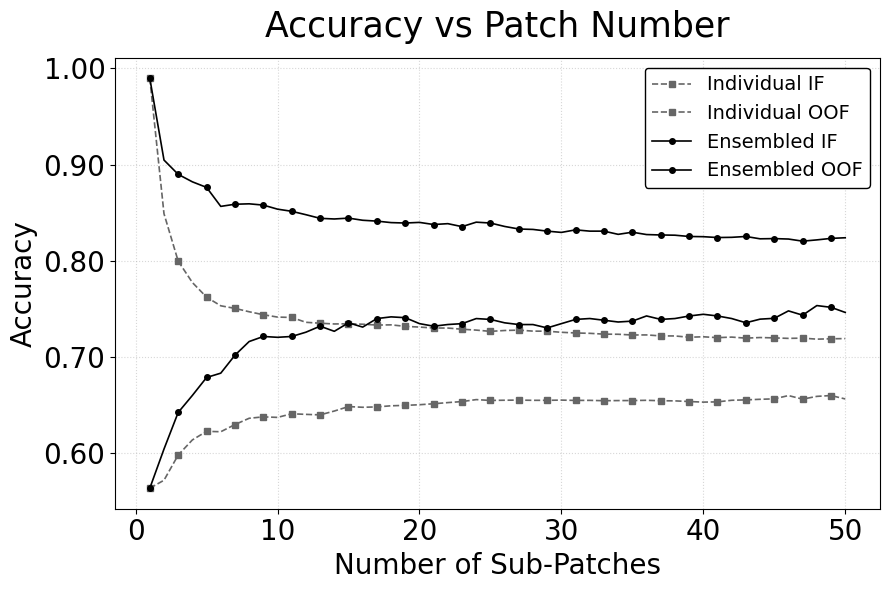

In [110]:
def show_patch_plot_total(df, if_oof='OOF', column='n_sub_patches'):
    if_oof = 'OOF'
    oof_if = 'IF'
        
    x = df[column]
    titles = {
        'n_sub_patches': 'Number of Sub-Patches',
        'gw': 'Fraction of Page Width',
        'n_writers': 'Number of Writers'
    }
    x_title = titles.get(column, column)

    y1 = df[f'ensembled_weighted_{if_oof}_accuracy_Mean']
    y2 = df[f'individual_{if_oof}_accuracy_Mean']
    y3 = df[f'ensembled_weighted_{oof_if}_accuracy_Mean']
    y4 = df[f'individual_{oof_if}_accuracy_Mean']

    sorted_idx = np.argsort(x)
    x_s = x.iloc[sorted_idx].values
    y1_s, y2_s, y3_s, y4_s = y1.iloc[sorted_idx], y2.iloc[sorted_idx], y3.iloc[sorted_idx], y4.iloc[sorted_idx]

    plt.figure(figsize=(9, 6))

    # SETTINGS FOR DENSE DATA
    m_size = 4        # Smaller markers
    l_width = 1.2     # Thinner lines
    m_every = 2       # Show a marker only every 2nd data point to reduce "cramming"

    # --- Group 1: Ensembled (Circles) ---
    light_gray='0.4'
    black = '0.0'
    
    plt.plot(x_s, y4_s, color=light_gray, linestyle='--', marker='s', 
             markersize=m_size, linewidth=l_width, markevery=m_every,
             label=f'Individual IF')
    
    plt.plot(x_s, y2_s, color=light_gray, linestyle='--', marker='s', 
             markersize=m_size, linewidth=l_width, markevery=m_every,
             label=f'Individual OOF')
    
    plt.plot(x_s, y3_s, color=black, linestyle='-', marker='o', 
             markersize=m_size, linewidth=l_width, markevery=m_every,
             label=f'Ensembled IF')
    
    plt.plot(x_s, y1_s, color=black, linestyle='-', marker='o', 
             markersize=m_size, linewidth=l_width, markevery=m_every,
             label=f'Ensembled OOF')

    # Formatting
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    plt.xlabel(x_title, fontsize=label_size)
    plt.ylabel('Accuracy', fontsize=label_size)
    plt.xticks(fontsize=tick_size)
    plt.yticks(fontsize=tick_size)
    
    # Large Legend
    plt.legend(fontsize=legend_size, loc='best', frameon=True, framealpha=1.0, edgecolor='black')
    
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.title('Accuracy vs Patch Number' , fontsize=title_size, pad=15)
    
    plt.tight_layout()
    plt.savefig(f'plot_{column}_{if_oof}_clean.pdf', bbox_inches='tight')
    plt.show()

show_patch_plot_total(df[df['FE model'] == 'clip-vit-large-patch14'], if_oof='OOF')

# easy access

In [3]:
def reload_modules():
    import importlib
    import utils.file_IO as file_IO
    
    importlib.reload(file_IO)

    return file_IO
file_IO = reload_modules()

In [9]:
def extends_with_info_from_source(df_input,df_pre_patch,columns=['unique name', 'type']):
    # For each row in df, map 'original raw file' to 'experiment' in df_pre_patch and extract 'unique name' and 'type'
    df = df_input.copy()
    df.drop(columns=['experiment'], inplace=True, errors='ignore')
    l=len(df)
    cols= ['experiment']+ columns
    df = df.merge(
        df_pre_patch[cols],
        left_on='original raw file',
        right_on='experiment',
        how='left'
    )
    assert len(df) == l, f"Length changed after merge: before={l}, after={len(df)}"
    return df

def select_accuracies(ensembling_types=['ensembled'],IF_OOF=['OOF'],metrics=['Mean'],groups=['all,all','english,all']):
    ''' returns the list of column names to extract given the specifiers'''
    selected_columns = []
    for group in groups:
        for ensembling_type in ensembling_types:
            for if_oof in IF_OOF:
                for metric in metrics:
                    if metric=='Generalization Gap':
                        if group == 'all,all':
                            selected_columns.append(f"{ensembling_type}_{metric}")
                        else:
                            selected_columns.append(f"{group}_{ensembling_type}_{metric}")
                    else:
                        if group == 'all,all':
                            selected_columns.append(f"{ensembling_type}_{if_oof}_accuracy_{metric}")
                        else:
                            selected_columns.append(f"{group}_{ensembling_type}_{if_oof}_accuracy_{metric}")
    # Remove duplicates from the selected_columns list while preserving order
    seen = set()
    selected_columns = [x for x in selected_columns if not (x in seen or seen.add(x))]
    return selected_columns

def expand_accuracies(df_source, types=['ensembled'],groups=['english,all']):
    df = df_source.copy()
    for type in types:
        df = expand_accuracies_specific(df, type=type)
    for group in groups:
        for type in types:
            df = expand_accuracies_specific(df, type=type, group=group)
    return df

def summarize_cv_results(train_accs, oof_accs, prefix=""):
    train_accs = np.array(train_accs)
    oof_accs = np.array(oof_accs)

    def compute_summary(arr):
        mean = np.mean(arr)
        variance = np.var(arr, ddof=1)  # Unbiased variance (sample variance)
        min_val = np.min(arr)
        max_val = np.max(arr)
        median = np.median(arr)
        ci_low, ci_high = st.t.interval(0.95, len(arr)-1, loc=mean, scale=st.sem(arr))
        return mean, variance, min_val, max_val, median, (ci_low, ci_high)

    train_summary = compute_summary(train_accs)
    oof_summary = compute_summary(oof_accs)

    generalization_gap = train_summary[0] - oof_summary[0]  # Difference in mean accuracies

    if_name="IF_accuracy_"
    oof_name="OOF_accuracy_"
    summary = {
            f"{prefix}_{if_name}Mean": train_summary[0],
            f"{prefix}_{if_name}Variance": train_summary[1],
            f"{prefix}_{if_name}Min": train_summary[2],
            f"{prefix}_{if_name}Max": train_summary[3],
            f"{prefix}_{if_name}Median": train_summary[4],
            f"{prefix}_{if_name}Confidence Interval": train_summary[5],
            f"{prefix}_{oof_name}Mean": oof_summary[0],
            f"{prefix}_{oof_name}Variance": oof_summary[1],
            f"{prefix}_{oof_name}Min": oof_summary[2],
            f"{prefix}_{oof_name}Max": oof_summary[3],
            f"{prefix}_{oof_name}Median": oof_summary[4],
            f"{prefix}_{oof_name}Confidence Interval": oof_summary[5],
            f"{prefix}_Generalization Gap": generalization_gap
        }

    return summary

def expand_accuracies_specific(df_source, type='ensembled',group=None):
    df= df_source.copy()
    new_columns = []
    if group is None:
        for idx, row in df.iterrows():
            c_val = row['cross_val_accuracies']
            IF_values = c_val['IF']
            #print(IF_values)
            accuracies_IF = []
            for value in IF_values: #value is a list of dict
                accuracies_IF.append(value[type])
            #print(accuracies_IF)
            OOF_values = c_val['OOF']
            accuracies_OOF = []
            for value in OOF_values:
                accuracies_OOF.append(value[type])
            summary=summarize_cv_results(accuracies_IF, accuracies_OOF,prefix=type)
            dict1 = {**summary}
            new_columns.append(dict1)
    else:
        for idx, row in df.iterrows():
            c_val = row['cross_val_subgroup_accuracies']
            summary = {}
            group_accuracies=[]
            for fold_accuracies in c_val:
                group_accuracies.append(fold_accuracies[group][type])
            summary=summarize_cv_results(group_accuracies, group_accuracies,prefix=group+'_'+type)
            dict1 = {**summary}
            new_columns.append(dict1)
    acc_df = pd.DataFrame(new_columns)
    df=pd.concat([df.reset_index(drop=True), acc_df.reset_index(drop=True)], axis=1)
    return df